In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from Log_Extractor import LogExtractor
from Fast_Log_Ext import Fast_LogExtractor
import joblib
import os

In [2]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 추적할 센서 연결 고리 (Sensor Pairs) 정의
# ==========================================
# Key: 시작 센서 -> Value: 끝나는 센서
SENSOR_CHAINS = {
    # --- 1. 전진 Unit 내부 사슬 ---
    "전진_1번_to_진입": ("전진Unit  캐리어 1번감지", "전진Unit  캐리어 진입감지"),
    "전진_진입_to_정위치": ("전진Unit  캐리어 진입감지", "전진Unit  캐리어 정위치감지"),
    
    # --- 2. 후진 Unit 내부 사슬 ---
    "후진_1번_to_진입": ("후진Unit  캐리어 1번감지", "후진Unit  캐리어  진입감지"),
    "후진_진입_to_정위치": ("후진Unit  캐리어  진입감지", "후진Unit  캐리어  정위치감지"),
    
    # --- 3. Air Unit 내부 사슬 ---
    "Air_진입_to_정위치": ("Air주입 Unit  캐리어 진입감지", "Air주입 Unit  캐리어 정위치감지"),

    "캐리어_진입_to_정위치": ("캐리어진입 1번 Check", "캐리어진입 Check") , 
    
    # --- 4. [핵심] Unit 간 연결 사슬 (메인 컨베이어 상태 대변) ---
    "전진_to_메인진입": ("전진Unit  캐리어 진입감지", "캐리어진입 Check"),
    "메인진입_to_후진": ("캐리어진입 Check", "후진Unit  캐리어  진입감지"),
    "후진_to_Air": ("후진Unit  캐리어  진입감지", "Air주입 Unit  캐리어 진입감지")
}

# 분석에 사용할 공통 태그
base_tags = [
    "전진_Actual_Wagon_Num",
    "후진_Actual_Wagon_Num",
    "Now_Actual_Wagon_Num",
    "Conv_SPD SET_HMI",
    "Hz_In_Conv",
    "CONVEYOR RUN / STOP PL_HMI",
    "AL_Line_Bit"
]
# 사슬에 포함된 모든 센서 이름 추출 (중복 제거)
sensor_tags = list(set([sensor for pair in SENSOR_CHAINS.values() for sensor in pair]))
all_target_tags = base_tags + sensor_tags

print("✅ 센서 사슬 설정 완료! 총 {}개의 피처(시간차)를 추적합니다.".format(len(SENSOR_CHAINS)))

✅ 센서 사슬 설정 완료! 총 9개의 피처(시간차)를 추적합니다.


In [3]:
fext = Fast_LogExtractor()

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!


In [4]:
raw_df = fext.get_data(start_time="2026-04-10T01:00:00Z", end_time="2026-04-14T15:00:00Z", target_tags=all_target_tags)

🚀 추출 시작: 2026-04-10 01:00:00 ~ 2026-04-14 15:00:00 (KST 기준)
📦 [Chunk 요청] 2026-04-10T01:00:00Z ~ 2026-04-10T07:00:00Z ... 성공 (9143행)
📦 [Chunk 요청] 2026-04-10T07:00:00Z ~ 2026-04-10T13:00:00Z ... 성공 (10287행)
📦 [Chunk 요청] 2026-04-10T13:00:00Z ~ 2026-04-10T19:00:00Z ... 성공 (10660행)
📦 [Chunk 요청] 2026-04-10T19:00:00Z ~ 2026-04-11T01:00:00Z ... 성공 (10777행)
📦 [Chunk 요청] 2026-04-11T01:00:00Z ~ 2026-04-11T07:00:00Z ... 성공 (10175행)
📦 [Chunk 요청] 2026-04-11T07:00:00Z ~ 2026-04-11T13:00:00Z ... 성공 (6382행)
📦 [Chunk 요청] 2026-04-11T13:00:00Z ~ 2026-04-11T19:00:00Z ... 성공 (10778행)
📦 [Chunk 요청] 2026-04-11T19:00:00Z ~ 2026-04-12T01:00:00Z ... 성공 (10600행)
📦 [Chunk 요청] 2026-04-12T01:00:00Z ~ 2026-04-12T07:00:00Z ... 성공 (10489행)
📦 [Chunk 요청] 2026-04-12T07:00:00Z ~ 2026-04-12T13:00:00Z ... 성공 (10762행)
📦 [Chunk 요청] 2026-04-12T13:00:00Z ~ 2026-04-12T19:00:00Z ... 성공 (10777행)
📦 [Chunk 요청] 2026-04-12T19:00:00Z ~ 2026-04-13T01:00:00Z ... 성공 (10198행)
📦 [Chunk 요청] 2026-04-13T01:00:00Z ~ 2026-04-13T07:00:00Z ... 성공 (1

In [6]:
raw_df.head()

,전진_Actual_Wagon_Num,후진_Actual_Wagon_Num,Now_Actual_Wagon_Num,Conv_SPD SET_HMI,Hz_In_Conv,CONVEYOR RUN / STOP PL_HMI,AL_Line_Bit,전진Unit 캐리어 정위치감지,후진Unit 캐리어 진입감지,Air주입 Unit 캐리어 정위치감지,전진Unit 캐리어 1번감지,후진Unit 캐리어 정위치감지,캐리어진입 1번 Check,후진Unit 캐리어 1번감지,캐리어진입 Check,Air주입 Unit 캐리어 진입감지,전진Unit 캐리어 진입감지
Time,,,,,,,,,,,,,,,,,
2026-04-10 10:38:49.029455,17.0,3.0,2.0,950.0,385.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2026-04-10 10:38:50.966164,17.0,3.0,2.0,950.0,385.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-04-10 10:38:52.967270,17.0,3.0,2.0,950.0,385.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2026-04-10 10:38:54.966549,17.0,3.0,2.0,950.0,385.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2026-04-10 10:38:57.237229,17.0,3.0,3.0,1000.0,405.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [7]:
import pandas as pd
import numpy as np

def prepare_health_training_features(raw_df):
    """
    과거 데이터를 입력받아 대차(Now_Actual_Wagon_Num) 단위로 
    센서 시간차와 버퍼 오프셋(물리적 간격)을 계산하여 반환합니다.
    """
    print("⏳ 학습용 피처 엔지니어링 시작...")
    df = raw_df.copy()
    
    # 1. 노이즈 제거: 가동 중이고, 라인 에러가 없는 정상 상태만 필터링
    df = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["AL_Line_Bit"] == 0)].copy()
    
    # 결측치 보정 (앞의 값으로 채움)
    df = df.ffill().fillna(0)
    
    # 2. 대차 번호(Now)가 바뀔 때마다 블록 ID 부여
    df['Wagon_Block'] = (df['Now_Actual_Wagon_Num'].diff() != 0).cumsum()
    
    features_list = []
    
    # 3. 블록(대차 1대 지나가는 과정) 단위로 그룹핑하여 계산
    for block_id, group in df.groupby('Wagon_Block'):
        # 노이즈/과도기 필터링: 데이터가 너무 적거나 속도가 0인 블록 제외
        if len(group) < 3 or group['Conv_SPD SET_HMI'].mode().empty:
            continue
            
        recipe_speed = group['Conv_SPD SET_HMI'].mode()[0]
        if recipe_speed <= 0:
            continue
            
        # 대표 대차 번호들 추출 (블록 내 최빈값 또는 마지막 값)
        now_wagon = group['Now_Actual_Wagon_Num'].iloc[-1]
        fwd_wagon = group['전진_Actual_Wagon_Num'].iloc[-1]
        bwd_wagon = group['후진_Actual_Wagon_Num'].iloc[-1]
        
        block_features = {
            'Wagon_Block': block_id,
            'Now_Actual_Wagon_Num': now_wagon,
            'Recipe_Speed': recipe_speed
        }
        
        # [피처 1] 물리적 간격 (Buffer Offsets) - 42대 윤곽 보정
        # 전진 - Now 간격
        offset_fwd = fwd_wagon - now_wagon
        if offset_fwd < -21: offset_fwd += 42
        elif offset_fwd > 21: offset_fwd -= 42
        block_features['Offset_FWD_NOW'] = offset_fwd
        
        # Now - 후진 간격
        offset_bwd = now_wagon - bwd_wagon
        if offset_bwd < -21: offset_bwd += 42
        elif offset_bwd > 21: offset_bwd -= 42
        block_features['Offset_NOW_BWD'] = offset_bwd
        
        # [피처 2] 센서 사슬 시간차 계산 (시간차 * 속도 = 거리 상수)
        for feature_name, (sensor_A, sensor_B) in SENSOR_CHAINS.items():
            # 0 -> 1로 변하는 엣지(Edge) 순간의 타임스탬프 추출
            edge_A_mask = (group[sensor_A] == 1) & (group[sensor_A].shift(1, fill_value=0) == 0)
            edge_B_mask = (group[sensor_B] == 1) & (group[sensor_B].shift(1, fill_value=0) == 0)
            
            time_A = group[edge_A_mask].index.min()
            time_B = group[edge_B_mask].index.min()
            
            if pd.notnull(time_A) and pd.notnull(time_B) and time_B >= time_A:
                delta_t = (time_B - time_A).total_seconds()
                normalized_distance = delta_t * recipe_speed
                block_features[feature_name] = normalized_distance
            else:
                # 에러: 센서가 안 찍혔거나 순서가 뒤집힘
                block_features[feature_name] = -1.0
                
        # [피처 3] 대차 번호 연속성 검증 (ID Jump)
        prev_now_wagon = df[df['Wagon_Block'] == block_id-1]['Now_Actual_Wagon_Num'].iloc[-1] if block_id > 1 else now_wagon
        id_diff = now_wagon - prev_now_wagon
        if id_diff < -21: id_diff += 42
        elif id_diff > 21: id_diff -= 42
        block_features['ID_Jump'] = id_diff
        
        features_list.append(block_features)
        
    result_df = pd.DataFrame(features_list)
    print(f"✅ 추출 완료! 총 {len(result_df)}대의 대차 통과 기록 생성.")
    return result_df

In [9]:
preprocessed_df = prepare_health_training_features(raw_df)
preprocessed_df.head(30)

⏳ 학습용 피처 엔지니어링 시작...
✅ 추출 완료! 총 12379대의 대차 통과 기록 생성.


,Wagon_Block,Now_Actual_Wagon_Num,Recipe_Speed,Offset_FWD_NOW,Offset_NOW_BWD,전진_1번_to_진입,전진_진입_to_정위치,후진_1번_to_진입,후진_진입_to_정위치,Air_진입_to_정위치,캐리어_진입_to_정위치,전진_to_메인진입,메인진입_to_후진,후진_to_Air,ID_Jump
0,1,2.0,950.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,0.0
1,2,3.0,1000.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
2,3,4.0,1000.0,15.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
3,4,5.0,1000.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
4,5,6.0,900.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
5,6,7.0,800.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
6,7,8.0,1000.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
7,8,9.0,1000.0,16.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
8,9,10.0,1000.0,15.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000,-1.0,1.0
9,10,11.0,1000.0,16.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1990.288,-1.0,1.0


In [ ]:
preprocessed_df.head(30)

In [40]:
def extract_snapshot_features(raw_df):
    print("⏳ Now_Wagon 기준 스냅샷 피처 추출 시작...")
    df = raw_df.copy()
    
    # 인덱스 중복 제거 및 노이즈 필터링
    df = df[~df.index.duplicated(keep='first')]
    df = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["AL_Line_Bit"] == 0)].copy()
    df = df.ffill().fillna(0)
    
    # 💡 형님의 핵심 아이디어: Now 번호가 바뀌는 구간을 하나의 '블록(스냅샷)'으로 정의
    df['Snapshot_Block'] = (df['Now_Actual_Wagon_Num'].diff() != 0).cumsum()
    features_list = []
    
    # 우리가 추적할 13개의 타겟 센서/대차번호 리스트 (Now 제외)
    target_sensors = [
        "전진_Actual_Wagon_Num", "후진_Actual_Wagon_Num",
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    for block_id, group in df.groupby('Snapshot_Block'):
        if len(group) < 3: # 너무 짧은 노이즈 블록 패스
            continue
            
        actual_speed = group['Hz_In_Conv'].mean()
        if actual_speed <= 5: 
            continue
            
        # 1. 스냅샷의 기준점 (T=0)
        t_zero = group.index.min()
        now_wagon = group['Now_Actual_Wagon_Num'].iloc[0]
        
        block_features = {
            'Block_ID': block_id,
            'Now_Wagon_Num': now_wagon,
            'Speed_Hz': actual_speed
        }
        
        # 2. 해당 스냅샷(8~12초) 내에서 나머지 센서들이 켜진 타이밍 찾기
        for sensor in target_sensors:
            if "Wagon_Num" in sensor:
                # 대차 번호는 '값이 변한 순간'을 찾음
                mask = group[sensor].diff() != 0
                mask.iloc[0] = False # 첫 행은 이전 블록과의 차이이므로 제외
                edge_times = group[mask.values].index
            else:
                # 센서는 '0 -> 1'로 켜진 순간을 찾음
                mask = (group[sensor] == 1) & (group[sensor].shift(1, fill_value=0) == 0)
                edge_times = group[mask.values].index
                
            # 가장 먼저 켜진 시간 추출
            first_edge_time = edge_times.min() if not edge_times.empty else pd.NaT
            
            # 피처 이름 깔끔하게 (예: "전진 정위치_Dist")
            feature_name = sensor.replace("Unit", "").replace("주입", "").replace("캐리어", "").strip() + "_Dist"
            
            # 3. 타이밍(초) * 컨베이어 속도 = 속도에 독립적인 '정규화 타이밍(거리)'
            if pd.notnull(first_edge_time):
                delta_t = (first_edge_time - t_zero).total_seconds()
                block_features[feature_name] = delta_t * actual_speed
            else:
                # 해당 스냅샷 안에서 켜지지 않은 센서는 0 (또는 NaN) 처리
                block_features[feature_name] = 0.0
                
        features_list.append(block_features)
        
    result_df = pd.DataFrame(features_list)
    print(f"✅ 스냅샷 피처 추출 완료! 총 {len(result_df)} 사이클 데이터 확보.")
    return result_df

In [25]:
# ==========================================
# 1. 추적할 센서 연결 고리 (Sensor Pairs) 정의
# ==========================================
# Key: 시작 센서 -> Value: 끝나는 센서
SENSOR_CHAINS = {
    # --- 전진 & 후진 유닛 ---
    "FWD_진입_to_정위치": ("전진_Actual_Wagon_Num", "전진Unit  캐리어 정위치감지"),
    "BWD_진입_to_정위치": ("후진_Actual_Wagon_Num", "후진Unit  캐리어  정위치감지"),
    
    # --- Air 주입 유닛 내부 시퀀스 ---
    "AIR_스톱퍼전진_to_정위치": ("Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지"),
    "AIR_정위치_to_Air1후진": ("Air주입 Unit  캐리어 정위치감지", "Air주입 Unit  캐리어  Air1주입 후진감지"),
    "AIR_Air1후진_to_스톱퍼후진": ("Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지"),
    "AIR_스톱퍼후진_to_유닛후진": ("Air주입 Unit  캐리어 스톱퍼 후진감지", "Air주입 Unit  캐리어  후진감지")
}

# 분석에 사용할 공통 태그
base_tags = [
    "전진_Actual_Wagon_Num",
    "후진_Actual_Wagon_Num",
    "Now_Actual_Wagon_Num",
    "Conv_SPD SET_HMI",
    "Hz_In_Conv",
    "CONVEYOR RUN / STOP PL_HMI",
    "AL_Line_Bit"
]
# 사슬에 포함된 모든 센서 이름 추출 (중복 제거)
sensor_tags = list(set([sensor for pair in SENSOR_CHAINS.values() for sensor in pair]))
all_target_tags = [
    "전진_Actual_Wagon_Num",
    "후진_Actual_Wagon_Num",
    "Now_Actual_Wagon_Num",
    "Conv_SPD SET_HMI",
    "Hz_In_Conv",
    "CONVEYOR RUN / STOP PL_HMI",
    "AL_Line_Bit",
    "전진Unit  캐리어 정위치감지",
    "후진Unit  캐리어  정위치감지",
    "Air주입 Unit  캐리어  스톱퍼 전진감지",
    "Air주입 Unit  캐리어 정위치감지",
    "Air주입 Unit  캐리어  Air1주입 후진감지",
    "Air주입 Unit  캐리어 스톱퍼 후진감지",
    "Air주입 Unit  캐리어  후진감지"
]

print("✅ 센서 사슬 설정 완료! 총 {}개의 피처(시간차)를 추적합니다.".format(len(SENSOR_CHAINS)))

✅ 센서 사슬 설정 완료! 총 6개의 피처(시간차)를 추적합니다.


In [23]:
raw_df = fext.get_data(start_time="2026-04-15T01:00:00Z", end_time="2026-04-15T15:00:00Z", target_tags=all_target_tags)

🚀 추출 시작: 2026-04-15 01:00:00 ~ 2026-04-15 15:00:00 (KST 기준)
📦 [Chunk 요청] 2026-04-15T01:00:00Z ~ 2026-04-15T07:00:00Z ... 성공 (9954행)
📦 [Chunk 요청] 2026-04-15T07:00:00Z ~ 2026-04-15T13:00:00Z ... 성공 (10566행)
📦 [Chunk 요청] 2026-04-15T13:00:00Z ~ 2026-04-15T15:00:00Z ... 성공 (3515행)
🔄 데이터 통합 및 KST 변환 중...
✅ 최종 추출 완료! 총 24035행, 14개 컬럼 확보.


In [27]:
raw_df

,전진_Actual_Wagon_Num,후진_Actual_Wagon_Num,Now_Actual_Wagon_Num,Conv_SPD SET_HMI,Hz_In_Conv,CONVEYOR RUN / STOP PL_HMI,AL_Line_Bit,전진Unit 캐리어 정위치감지,후진Unit 캐리어 정위치감지,Air주입 Unit 캐리어 스톱퍼 전진감지,Air주입 Unit 캐리어 정위치감지,Air주입 Unit 캐리어 Air1주입 후진감지,Air주입 Unit 캐리어 스톱퍼 후진감지,Air주입 Unit 캐리어 후진감지
Time,,,,,,,,,,,,,,
2026-04-15 10:00:00.513599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
2026-04-15 10:00:02.498778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
2026-04-15 10:00:05.078919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2026-04-15 10:00:06.524258,31.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,NaN
2026-04-15 10:00:09.091150,31.0,17.0,16.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-15 23:59:51.273978,39.0,24.0,24.0,1000.0,405.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2026-04-15 23:59:53.270077,39.0,24.0,24.0,1000.0,405.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2026-04-15 23:59:55.275350,39.0,24.0,24.0,1000.0,405.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


In [41]:
re_df = extract_snapshot_features(raw_df)

⏳ Now_Wagon 기준 스냅샷 피처 추출 시작...
✅ 스냅샷 피처 추출 완료! 총 3140 사이클 데이터 확보.


In [42]:
re_df.head(30)

,Block_ID,Now_Wagon_Num,Speed_Hz,전진_Actual_Wagon_Num_Dist,후진_Actual_Wagon_Num_Dist,전진 정위치감지_Dist,후진 정위치감지_Dist,Air 스톱퍼 전진감지_Dist,Air 정위치감지_Dist,Air Air1 후진감지_Dist,Air 스톱퍼 후진감지_Dist,Air 후진감지_Dist
0,2,21.0,405.0,4451.094990,0.000000,0.000000,0.0,0.00000,911.709270,911.709270,911.709270,0.0
1,3,24.0,405.0,3341.764350,0.000000,806.189355,0.0,3341.76435,0.000000,0.000000,0.000000,0.0
2,4,25.0,385.0,0.000000,0.000000,0.000000,0.0,0.00000,776.609680,776.609680,776.609680,0.0
3,5,26.0,405.0,4873.345560,829.099800,0.000000,0.0,0.00000,1529.663130,829.099800,1529.663130,0.0
4,6,27.0,405.0,3949.688385,0.000000,0.000000,0.0,0.00000,810.342630,810.342630,810.342630,0.0
5,7,28.0,405.0,3965.049630,0.000000,0.000000,0.0,0.00000,722.609100,722.609100,722.609100,0.0
6,8,29.0,405.0,4147.852455,699.835950,0.000000,0.0,0.00000,1511.850420,699.835950,699.835950,0.0
7,9,30.0,405.0,0.000000,809.756190,0.000000,0.0,0.00000,1722.686940,809.756190,1722.686940,0.0
8,10,31.0,405.0,4767.512580,911.276325,0.000000,0.0,0.00000,1624.514940,911.276325,1624.514940,0.0
9,11,32.0,324.0,3484.631340,0.000000,0.000000,0.0,0.00000,477.196596,477.196596,477.196596,0.0


In [43]:
import pandas as pd
import numpy as np

def extract_snapshot_features_v2(raw_df):
    print("⏳ 개선된 스냅샷 피처 추출 시작 (윈도우 탐색 적용)...")
    df = raw_df.copy()
    
    # 1. 전처리
    df = df[~df.index.duplicated(keep='first')]
    df = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["AL_Line_Bit"] == 0)].copy()
    df = df.ffill().fillna(0)
    
    # 2. 전체 데이터에서 각 센서별 '0 -> 1' 엣지 발생 시간들을 미리 쫙 뽑아둠 (핵심 변경점!)
    target_sensors = [
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    sensor_edge_dict = {}
    for sensor in target_sensors:
        mask = (df[sensor] == 1) & (df[sensor].shift(1, fill_value=0) == 0)
        sensor_edge_dict[sensor] = df[mask].index

    # Now 번호가 바뀌는 순간(T=0)들 추출
    now_mask = df['Now_Actual_Wagon_Num'].diff() != 0
    now_mask.iloc[0] = False 
    t_zero_times = df[now_mask].index

    features_list = []
    
    # 3. 각 T=0 순간을 기준으로 피처 계산
    for i, t_zero in enumerate(t_zero_times):
        # 해당 순간의 컨베이어 상태값 가져오기
        row = df.loc[t_zero]
        actual_speed = row['Hz_In_Conv']
        now_wagon = row['Now_Actual_Wagon_Num']
        
        if actual_speed <= 5: 
            continue
            
        block_features = {
            'Now_Wagon_Num': now_wagon,
            'Speed_Hz': actual_speed
        }
        
        # 4. T=0을 기준으로 가장 가까운 센서 엣지 찾기
        for sensor in target_sensors:
            edges = sensor_edge_dict[sensor]
            if edges.empty:
                block_features[sensor + "_Dist"] = 0.0
                continue
                
            # T=0 이후에 발생한 엣지 중 가장 가까운 것 찾기
            # (만약 이전 엣지도 허용하려면 로직을 살짝 수정해야 함. 일단은 T=0 직후만 봄)
            future_edges = edges[edges >= t_zero]
            
            if not future_edges.empty:
                first_edge = future_edges[0]
                # T=0과 센서가 켜진 시간 차이가 너무 크면(예: 15초 이상) 다른 대차의 신호로 간주
                delta_t = (first_edge - t_zero).total_seconds()
                
                if delta_t < 15.0: # 15초 윈도우 설정
                    block_features[sensor + "_Dist"] = delta_t * actual_speed
                else:
                    block_features[sensor + "_Dist"] = 0.0
            else:
                block_features[sensor + "_Dist"] = 0.0
                
        features_list.append(block_features)
        
    result_df = pd.DataFrame(features_list)
    print(f"✅ 추출 완료! 총 {len(result_df)} 사이클 데이터 확보.")
    return result_df

In [44]:
rew_df = extract_snapshot_features_v2(raw_df)

⏳ 개선된 스냅샷 피처 추출 시작 (윈도우 탐색 적용)...
✅ 추출 완료! 총 3161 사이클 데이터 확보.


In [46]:
rew_df.tail(30)

,Now_Wagon_Num,Speed_Hz,전진Unit 캐리어 정위치감지_Dist,후진Unit 캐리어 정위치감지_Dist,Air주입 Unit 캐리어 스톱퍼 전진감지_Dist,Air주입 Unit 캐리어 정위치감지_Dist,Air주입 Unit 캐리어 Air1주입 후진감지_Dist,Air주입 Unit 캐리어 스톱퍼 후진감지_Dist,Air주입 Unit 캐리어 후진감지_Dist
3131,36.0,405.0,3245.383260,4156.132275,0.0,0.0,0.0,0.0,0.0
3132,37.0,405.0,3238.178310,4050.853335,0.0,0.0,0.0,0.0,0.0
3133,38.0,405.0,2434.626720,3250.510155,0.0,0.0,0.0,0.0,0.0
3134,39.0,405.0,3236.452605,3236.452605,0.0,0.0,0.0,0.0,0.0
3135,40.0,405.0,3249.530055,3249.530055,0.0,0.0,0.0,0.0,0.0
3136,41.0,405.0,3243.645810,4052.571750,0.0,0.0,0.0,0.0,0.0
3137,42.0,405.0,2439.508995,3250.112445,0.0,0.0,0.0,0.0,0.0
3138,1.0,405.0,3241.288710,3241.288710,0.0,0.0,0.0,0.0,0.0
3139,2.0,405.0,3252.465900,3252.465900,0.0,0.0,0.0,0.0,0.0
3140,3.0,405.0,3147.379335,3964.312530,0.0,0.0,0.0,0.0,0.0


In [52]:
import pandas as pd

def extract_macro_duty_cycle_features(raw_df, window_minutes=5):
    print(f"⏳ {window_minutes}분 단위 거시적 점유율(Duty Cycle) 피처 추출 시작...")
    df = raw_df.copy()
    
    # 💡 [핵심 에러 해결] 인덱스를 무조건 시간(Datetime) 타입으로 강제 변환하고 시간순으로 정렬!
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
    # 노이즈 제거 (가동 중이고 에러 없을 때만)
    df = df[~df.index.duplicated(keep='first')]
    df = df[(df["CONVEYOR RUN / STOP PL_HMI"] == 1) & (df["AL_Line_Bit"] == 0)].copy()
    df = df.ffill().fillna(0)
    
    # 분석할 타겟 센서들
    boolean_sensors = [
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    # 💡 판다스 최신 버전에 맞춘 분 단위 포맷 'min' 사용 (예: '5min')
    window_str = f'{window_minutes}min'
    
    # 거시적 롤링 (점유율 및 평균 속도 계산)
    df_macro_sensors = df[boolean_sensors].rolling(window=window_str, min_periods=10).mean()
    df_macro_speed = df[['Hz_In_Conv']].rolling(window=window_str, min_periods=10).mean()
    
    # 피처 병합
    macro_features = pd.concat([df_macro_speed, df_macro_sensors], axis=1)
    macro_features = macro_features.dropna() # 초기 윈도우 결측치 제거
    
    # [핵심] 점유율(%) * 평균 속도 = 'Load Score' 계산
    for sensor in boolean_sensors:
        feature_name = sensor.replace("Unit", "").replace("주입", "").replace("캐리어", "").strip() + "_Load_Score"
        macro_features[feature_name] = macro_features[sensor] * macro_features['Hz_In_Conv']
        
    # 최종 결과물 정리
    cols_to_keep = ['Hz_In_Conv'] + [c for c in macro_features.columns if "_Load_Score" in c]
    
    print(f"✅ 추출 완료! 데이터 틱마다 거시적 건강도 스코어가 매핑되었습니다.")
    
    # 너무 촘촘하면 보기 힘드니 1분 단위로 묶어서 반환
    return macro_features[cols_to_keep].resample('1min').mean().dropna()

# 실행 테스트
# final_macro_features = extract_macro_duty_cycle_features(raw_df, window_minutes=5)
# print(final_macro_features.head())

In [53]:
reqw_df = extract_macro_duty_cycle_features(raw_df, window_minutes=5)

⏳ 5분 단위 거시적 점유율(Duty Cycle) 피처 추출 시작...
✅ 추출 완료! 데이터 틱마다 거시적 건강도 스코어가 매핑되었습니다.


In [55]:
fext.save_to_csv(reqw_df)

💾 [저장 완료] 분석용 CSV 파일이 생성되었습니다: ./extracted_csv/2026-04-17_161159_analysis.csv


In [56]:
def extract_trimmed_duty_cycle_features(raw_df, window_minutes=5, trim_front_min=20, trim_back_min=10):
    print(f"⏳ {window_minutes}분 단위 점유율 분석 시작 (앞 {trim_front_min}분, 뒤 {trim_back_min}분 과도기 제거)...")
    df = raw_df.copy()
    
    # 1. 인덱스 강제 시간 타입 변환 및 정렬 (판다스 에러 방지)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    df = df.ffill().fillna(0)
    
    # 2. 가동 세션(Session) 분리 로직
    # CONVEYOR RUN 신호가 0에서 1로, 또는 1에서 0으로 바뀔 때마다 그룹 ID를 증가시킴
    is_running = df["CONVEYOR RUN / STOP PL_HMI"] == 1
    df['Session_ID'] = (is_running != is_running.shift()).cumsum()
    
    # RUN == 1인 세션만 남기기
    df_run = df[is_running].copy()
    
    # 3. 각 세션별로 앞뒤 잘라내기 (Trimming)
    steady_blocks = []
    for session_id, session_data in df_run.groupby('Session_ID'):
        if session_data.empty:
            continue
            
        # 세션의 총 가동 시간 계산
        session_start = session_data.index[0]
        session_end = session_data.index[-1]
        session_duration = session_end - session_start
        
        # 앞뒤 자를 시간보다 세션이 짧으면 통째로 버림 (최소 30분 이상 가동된 세션만 인정)
        min_required_duration = pd.Timedelta(minutes=(trim_front_min + trim_back_min))
        if session_duration <= min_required_duration:
            print(f"  - 세션 {session_id} 패스: 가동 시간({session_duration})이 너무 짧습니다.")
            continue
            
        # 자를 시간 계산 (시간 축 기준)
        valid_start = session_start + pd.Timedelta(minutes=trim_front_min)
        valid_end = session_end - pd.Timedelta(minutes=trim_back_min)
        
        # 싹둑 자르기
        steady_data = session_data[(session_data.index >= valid_start) & (session_data.index <= valid_end)].copy()
        
        # 라인 에러(AL_Line_Bit == 1)가 있는 구간 제거
        steady_data = steady_data[steady_data["AL_Line_Bit"] == 0]
        
        if not steady_data.empty:
            steady_blocks.append(steady_data)
            
    if not steady_blocks:
        print("⚠️ 조건(30분 이상 가동 등)을 만족하는 유효한 데이터가 없습니다.")
        return pd.DataFrame()
        
    # 잘라낸 정상(Steady) 데이터들만 다시 합체
    df_steady = pd.concat(steady_blocks).sort_index()
    print(f"✂️ 트리밍 완료! 총 {len(df_steady)} 틱의 안정화(Steady) 데이터 확보.")

    # 4. 분석할 타겟 센서들 (1/0으로 깜빡이는 센서만)
    boolean_sensors = [
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    # 5. 거시적 롤링 (점유율 계산)
    window_str = f'{window_minutes}min'
    df_macro_sensors = df_steady[boolean_sensors].rolling(window=window_str, min_periods=10).mean()
    df_macro_speed = df_steady[['Hz_In_Conv']].rolling(window=window_str, min_periods=10).mean()
    
    macro_features = pd.concat([df_macro_speed, df_macro_sensors], axis=1).dropna()
    
    # 6. [핵심] 점유율(%) * 평균 속도 = 'Load Score' 계산
    for sensor in boolean_sensors:
        feature_name = sensor.replace("Unit", "").replace("주입", "").replace("캐리어", "").strip() + "_Load_Score"
        # 점유율(0~1) * 주파수(Hz) = 속도 변화에 독립적인 기구부 부하량
        macro_features[feature_name] = macro_features[sensor] * macro_features['Hz_In_Conv']
        
    # 결과 정리
    cols_to_keep = ['Hz_In_Conv'] + [c for c in macro_features.columns if "_Load_Score" in c]
    final_df = macro_features[cols_to_keep].resample('1min').mean().dropna()
    
    print(f"✅ 점유율 피처 추출 성공! 총 {len(final_df)}분(Minute) 분량의 시계열 데이터 완성.")
    return final_df

# 🚀 실행 테스트
# final_macro_features = extract_trimmed_duty_cycle_features(raw_df, window_minutes=5, trim_front_min=20, trim_back_min=10)
# display(final_macro_features.head())

In [59]:
qqwet_df = extract_trimmed_duty_cycle_features(raw_df, window_minutes=5, trim_front_min=25, trim_back_min=10)

⏳ 5분 단위 점유율 분석 시작 (앞 25분, 뒤 10분 과도기 제거)...
  - 세션 4 패스: 가동 시간(0 days 00:00:04.275484)이 너무 짧습니다.
  - 세션 6 패스: 가동 시간(0 days 00:07:16.596179)이 너무 짧습니다.
  - 세션 8 패스: 가동 시간(0 days 00:23:10.020151)이 너무 짧습니다.
  - 세션 12 패스: 가동 시간(0 days 00:00:39.978477)이 너무 짧습니다.
  - 세션 16 패스: 가동 시간(0 days 00:00:11.671820)이 너무 짧습니다.
  - 세션 18 패스: 가동 시간(0 days 00:17:58.177159)이 너무 짧습니다.
  - 세션 24 패스: 가동 시간(0 days 00:00:00)이 너무 짧습니다.
  - 세션 26 패스: 가동 시간(0 days 00:00:34.031496)이 너무 짧습니다.
  - 세션 28 패스: 가동 시간(0 days 00:02:16.340922)이 너무 짧습니다.
  - 세션 32 패스: 가동 시간(0 days 00:00:24.197761)이 너무 짧습니다.
  - 세션 36 패스: 가동 시간(0 days 00:00:16.559238)이 너무 짧습니다.
  - 세션 38 패스: 가동 시간(0 days 00:04:49.210775)이 너무 짧습니다.
  - 세션 40 패스: 가동 시간(0 days 00:00:42.075894)이 너무 짧습니다.
  - 세션 42 패스: 가동 시간(0 days 00:00:01.998810)이 너무 짧습니다.
  - 세션 44 패스: 가동 시간(0 days 00:01:44.223610)이 너무 짧습니다.
  - 세션 46 패스: 가동 시간(0 days 00:06:34.878941)이 너무 짧습니다.
✂️ 트리밍 완료! 총 10791 틱의 안정화(Steady) 데이터 확보.
✅ 점유율 피처 추출 성공! 총 381분(Minute) 분량의 시계열 데이터 완성.


In [60]:
fext.save_to_csv(qqwet_df)

💾 [저장 완료] 분석용 CSV 파일이 생성되었습니다: ./extracted_csv/2026-04-17_171317_analysis.csv


📊 총 7개의 정규화 거리(Dist) 피처에 대한 검증 그래프를 그립니다...


/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


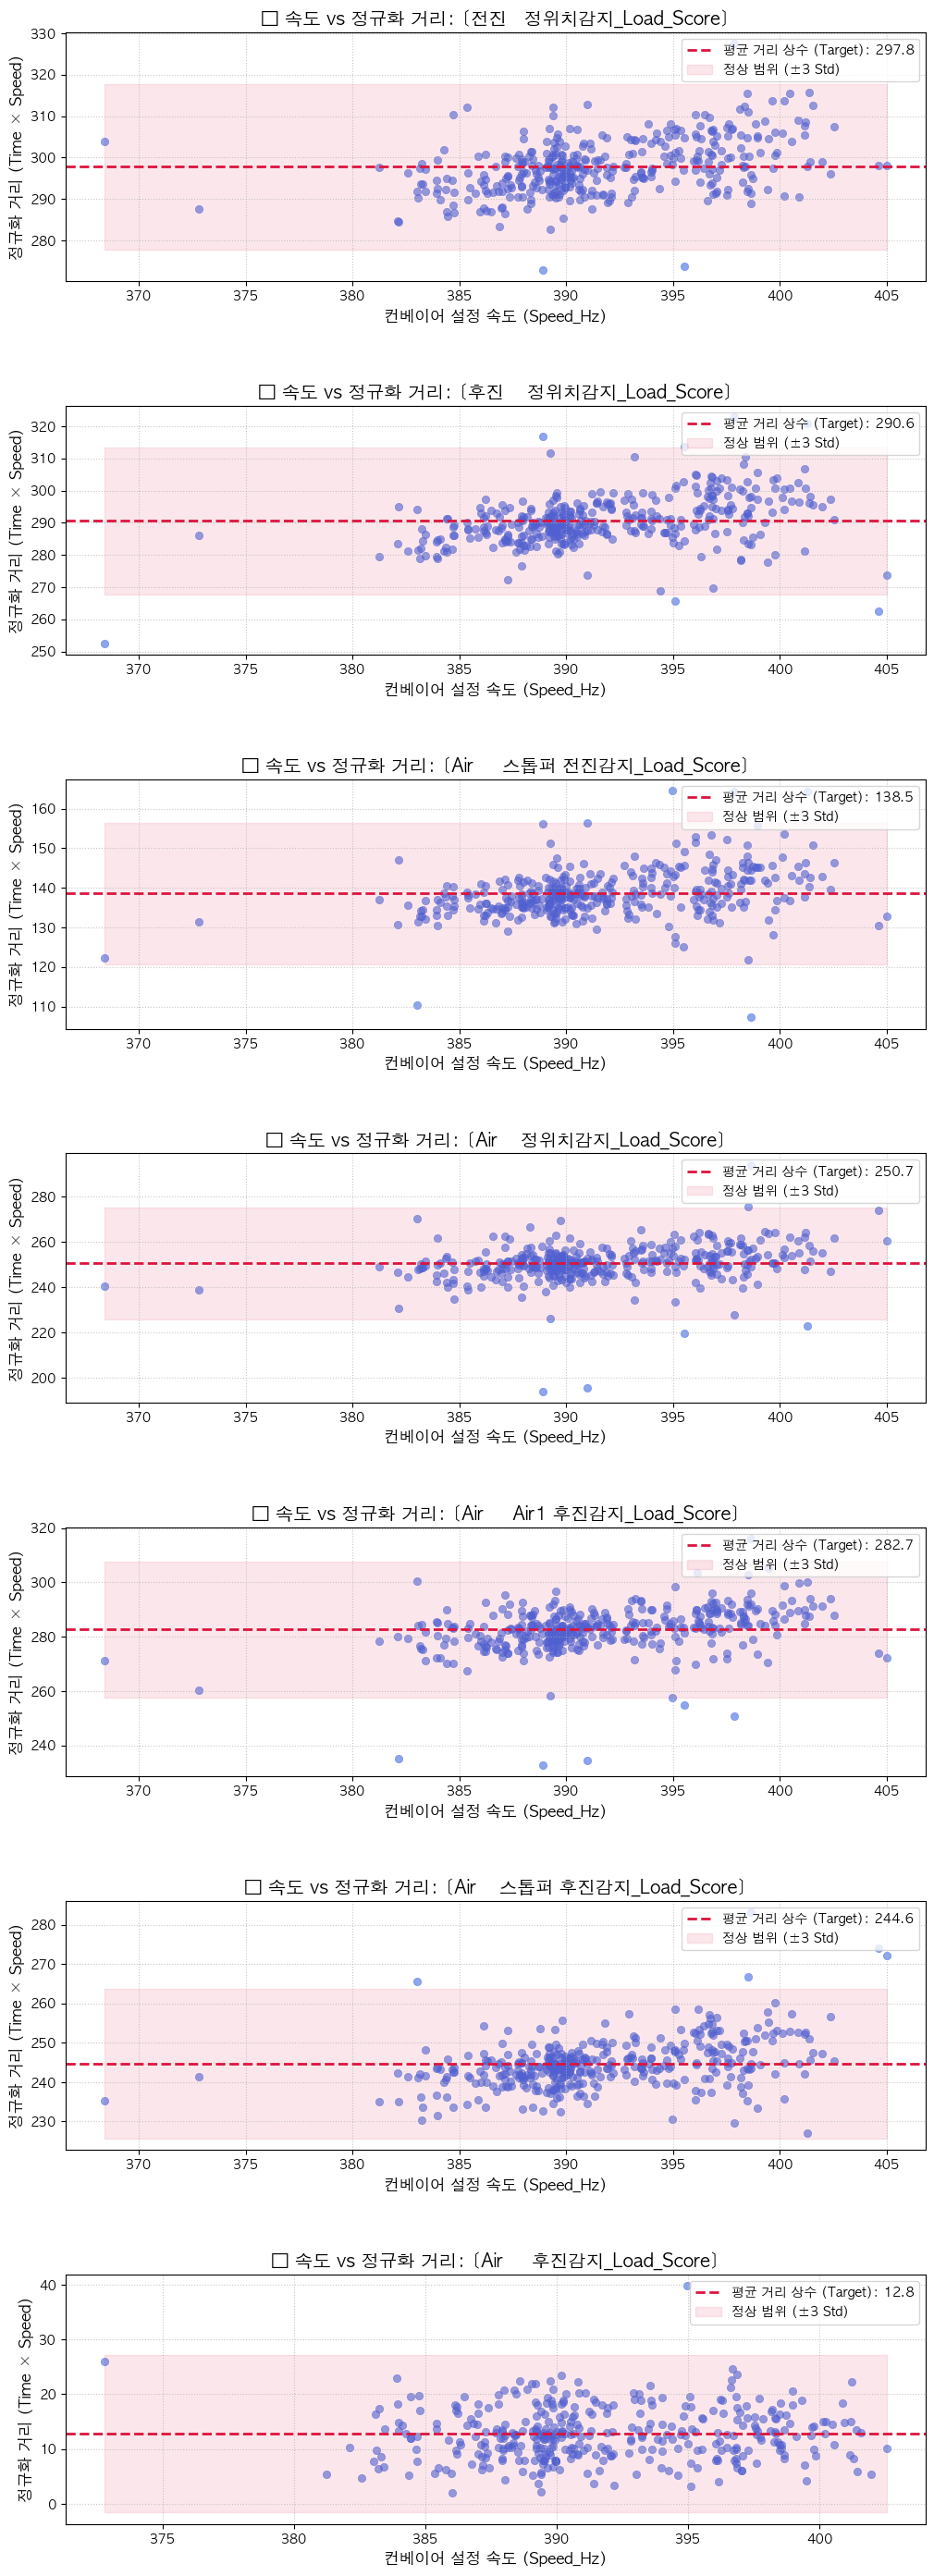

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. 한글 폰트 및 마이너스 깨짐 방지 설정
# ==========================================
if os.name == 'nt':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Mac
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

def plot_normalized_distances(df):
    # 2. '_Dist'로 끝나는 타겟 컬럼만 싹 다 찾기
    dist_cols = [col for col in df.columns if col.endswith('_Load_Score')]
    
    print(f"📊 총 {len(dist_cols)}개의 정규화 거리(Dist) 피처에 대한 검증 그래프를 그립니다...")
    
    # 3. 그래프 도화지 세팅 (세로로 길게 나열)
    fig, axes = plt.subplots(len(dist_cols), 1, figsize=(12, 5 * len(dist_cols)))
    plt.subplots_adjust(hspace=0.5) # 그래프 사이 간격 넉넉하게
    
    # 컬럼이 1개일 때를 대비한 예외 처리
    if len(dist_cols) == 1:
        axes = [axes]
        
    # 4. 각 컬럼별로 산점도(Scatter Plot) 그리기
    for ax, col in zip(axes, dist_cols):
        # 노이즈(0.0)로 처리된 데이터는 시각화에서 제외해서 축 스케일 꼬임 방지
        valid_df = df[df[col] > 0]
        
        # 속도(X)에 따른 거리(Y) 산점도
        sns.scatterplot(data=valid_df, x='Hz_In_Conv', y=col, ax=ax, alpha=0.6, color='royalblue', edgecolor=None)
        
        # 💡 [핵심] 이상적인 물리 상수(평균값)를 붉은 점선으로 표시
        if not valid_df.empty:
            mean_val = valid_df[col].mean()
            std_val = valid_df[col].std()
            
            ax.axhline(mean_val, color='crimson', linestyle='--', linewidth=2, 
                       label=f'평균 거리 상수 (Target): {mean_val:.1f}')
            
            # 정상 허용 범위 (3-Sigma) 색칠하기 (선택 사항, 눈으로 분산 보기 좋음)
            ax.fill_between([valid_df['Hz_In_Conv'].min(), valid_df['Hz_In_Conv'].max()], 
                            mean_val - 3*std_val, mean_val + 3*std_val, 
                            color='crimson', alpha=0.1, label='정상 범위 (±3 Std)')
        
        # 그래프 꾸미기
        ax.set_title(f"🚀 속도 vs 정규화 거리: [{col}]", fontsize=14, fontweight='bold')
        ax.set_xlabel("컨베이어 설정 속도 (Speed_Hz)", fontsize=12)
        ax.set_ylabel("정규화 거리 (Time × Speed)", fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.7)
        
    plt.show()

# 🚀 실행 방법
# 아까 뽑아둔 데이터프레임 이름(예: final_features)을 넣어주시면 됩니다.
plot_normalized_distances(qqwet_df)

In [68]:
def extract_trimmed_duty_cycle_features_vv2(raw_df, window_minutes=5, trim_front_min=20, trim_back_min=10):
    print(f"⏳ {window_minutes}분 단위 점유율 분석 시작 (앞 {trim_front_min}분, 뒤 {trim_back_min}분 과도기 제거)...")
    df = raw_df.copy()
    
    # 1. 인덱스 강제 시간 타입 변환 및 정렬 (판다스 에러 방지)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[~df.index.duplicated(keep='first')]
    df = df.ffill().fillna(0)
    
    # 2. 가동 세션(Session) 분리 로직
    # CONVEYOR RUN 신호가 0에서 1로, 또는 1에서 0으로 바뀔 때마다 그룹 ID를 증가시킴
    is_running = df["CONVEYOR RUN / STOP PL_HMI"] == 1
    df['Session_ID'] = (is_running != is_running.shift()).cumsum()
    
    # RUN == 1인 세션만 남기기
    df_run = df[is_running].copy()
    
    # 3. 각 세션별로 앞뒤 잘라내기 (Trimming)
    steady_blocks = []
    for session_id, session_data in df_run.groupby('Session_ID'):
        if session_data.empty:
            continue
            
        # 세션의 총 가동 시간 계산
        session_start = session_data.index[0]
        session_end = session_data.index[-1]
        session_duration = session_end - session_start
        
        # 앞뒤 자를 시간보다 세션이 짧으면 통째로 버림 (최소 30분 이상 가동된 세션만 인정)
        min_required_duration = pd.Timedelta(minutes=(trim_front_min + trim_back_min))
        if session_duration <= min_required_duration:
            print(f"  - 세션 {session_id} 패스: 가동 시간({session_duration})이 너무 짧습니다.")
            continue
            
        # 자를 시간 계산 (시간 축 기준)
        valid_start = session_start + pd.Timedelta(minutes=trim_front_min)
        valid_end = session_end - pd.Timedelta(minutes=trim_back_min)
        
        # 싹둑 자르기
        steady_data = session_data[(session_data.index >= valid_start) & (session_data.index <= valid_end)].copy()
        
        # 라인 에러(AL_Line_Bit == 1)가 있는 구간 제거
        steady_data = steady_data[steady_data["AL_Line_Bit"] == 0]
        
        if not steady_data.empty:
            steady_blocks.append(steady_data)
            
    if not steady_blocks:
        print("⚠️ 조건(30분 이상 가동 등)을 만족하는 유효한 데이터가 없습니다.")
        return pd.DataFrame()
        
    # 잘라낸 정상(Steady) 데이터들만 다시 합체
    df_steady = pd.concat(steady_blocks).sort_index()
    print(f"✂️ 트리밍 완료! 총 {len(df_steady)} 틱의 안정화(Steady) 데이터 확보.")

    # 4. 분석할 타겟 센서들 (1/0으로 깜빡이는 센서만)
    boolean_sensors = [
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    # 5. 거시적 롤링 (점유율 계산)
    window_str = f'{window_minutes}min'
    df_macro_sensors = df_steady[boolean_sensors].rolling(window=window_str, min_periods=10).mean()
    df_macro_speed = df_steady[['Hz_In_Conv']].rolling(window=window_str, min_periods=10).mean()
    
    macro_features = pd.concat([df_macro_speed, df_macro_sensors], axis=1).dropna()
    
    # 6. [핵심] 점유율(%) * 평균 속도 = 'Load Score' 계산
    for sensor in boolean_sensors:
        feature_name = sensor.replace("Unit", "").replace("주입", "").replace("캐리어", "").strip() + "_Load_Score"
        # 점유율(0~1) * 주파수(Hz) = 속도 변화에 독립적인 기구부 부하량
        macro_features[feature_name] = macro_features[sensor] * macro_features['Hz_In_Conv']
        
    # 결과 정리
    cols_to_keep = ['Hz_In_Conv'] + boolean_sensors + [c for c in macro_features.columns if "_Load_Score" in c]
    final_df = macro_features[cols_to_keep].resample('1min').mean().dropna()
    
    print(f"✅ 점유율 피처 추출 성공! 총 {len(final_df)}분(Minute) 분량의 시계열 데이터 완성.")
    return final_df

# 🚀 실행 테스트
final_macro_features = extract_trimmed_duty_cycle_features_vv2(raw_df, window_minutes=5, trim_front_min=20, trim_back_min=10)
# display(final_macro_features.head())

⏳ 5분 단위 점유율 분석 시작 (앞 20분, 뒤 10분 과도기 제거)...
  - 세션 4 패스: 가동 시간(0 days 00:00:04.275484)이 너무 짧습니다.
  - 세션 6 패스: 가동 시간(0 days 00:07:16.596179)이 너무 짧습니다.
  - 세션 8 패스: 가동 시간(0 days 00:23:10.020151)이 너무 짧습니다.
  - 세션 12 패스: 가동 시간(0 days 00:00:39.978477)이 너무 짧습니다.
  - 세션 16 패스: 가동 시간(0 days 00:00:11.671820)이 너무 짧습니다.
  - 세션 18 패스: 가동 시간(0 days 00:17:58.177159)이 너무 짧습니다.
  - 세션 24 패스: 가동 시간(0 days 00:00:00)이 너무 짧습니다.
  - 세션 26 패스: 가동 시간(0 days 00:00:34.031496)이 너무 짧습니다.
  - 세션 28 패스: 가동 시간(0 days 00:02:16.340922)이 너무 짧습니다.
  - 세션 32 패스: 가동 시간(0 days 00:00:24.197761)이 너무 짧습니다.
  - 세션 36 패스: 가동 시간(0 days 00:00:16.559238)이 너무 짧습니다.
  - 세션 38 패스: 가동 시간(0 days 00:04:49.210775)이 너무 짧습니다.
  - 세션 40 패스: 가동 시간(0 days 00:00:42.075894)이 너무 짧습니다.
  - 세션 42 패스: 가동 시간(0 days 00:00:01.998810)이 너무 짧습니다.
  - 세션 44 패스: 가동 시간(0 days 00:01:44.223610)이 너무 짧습니다.
  - 세션 46 패스: 가동 시간(0 days 00:06:34.878941)이 너무 짧습니다.
✂️ 트리밍 완료! 총 11831 틱의 안정화(Steady) 데이터 확보.
✅ 점유율 피처 추출 성공! 총 416분(Minute) 분량의 시계열 데이터 완성.


📈 컨베이어 속도에 따른 [정상 점유율 기대 곡선]을 그립니다...


/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


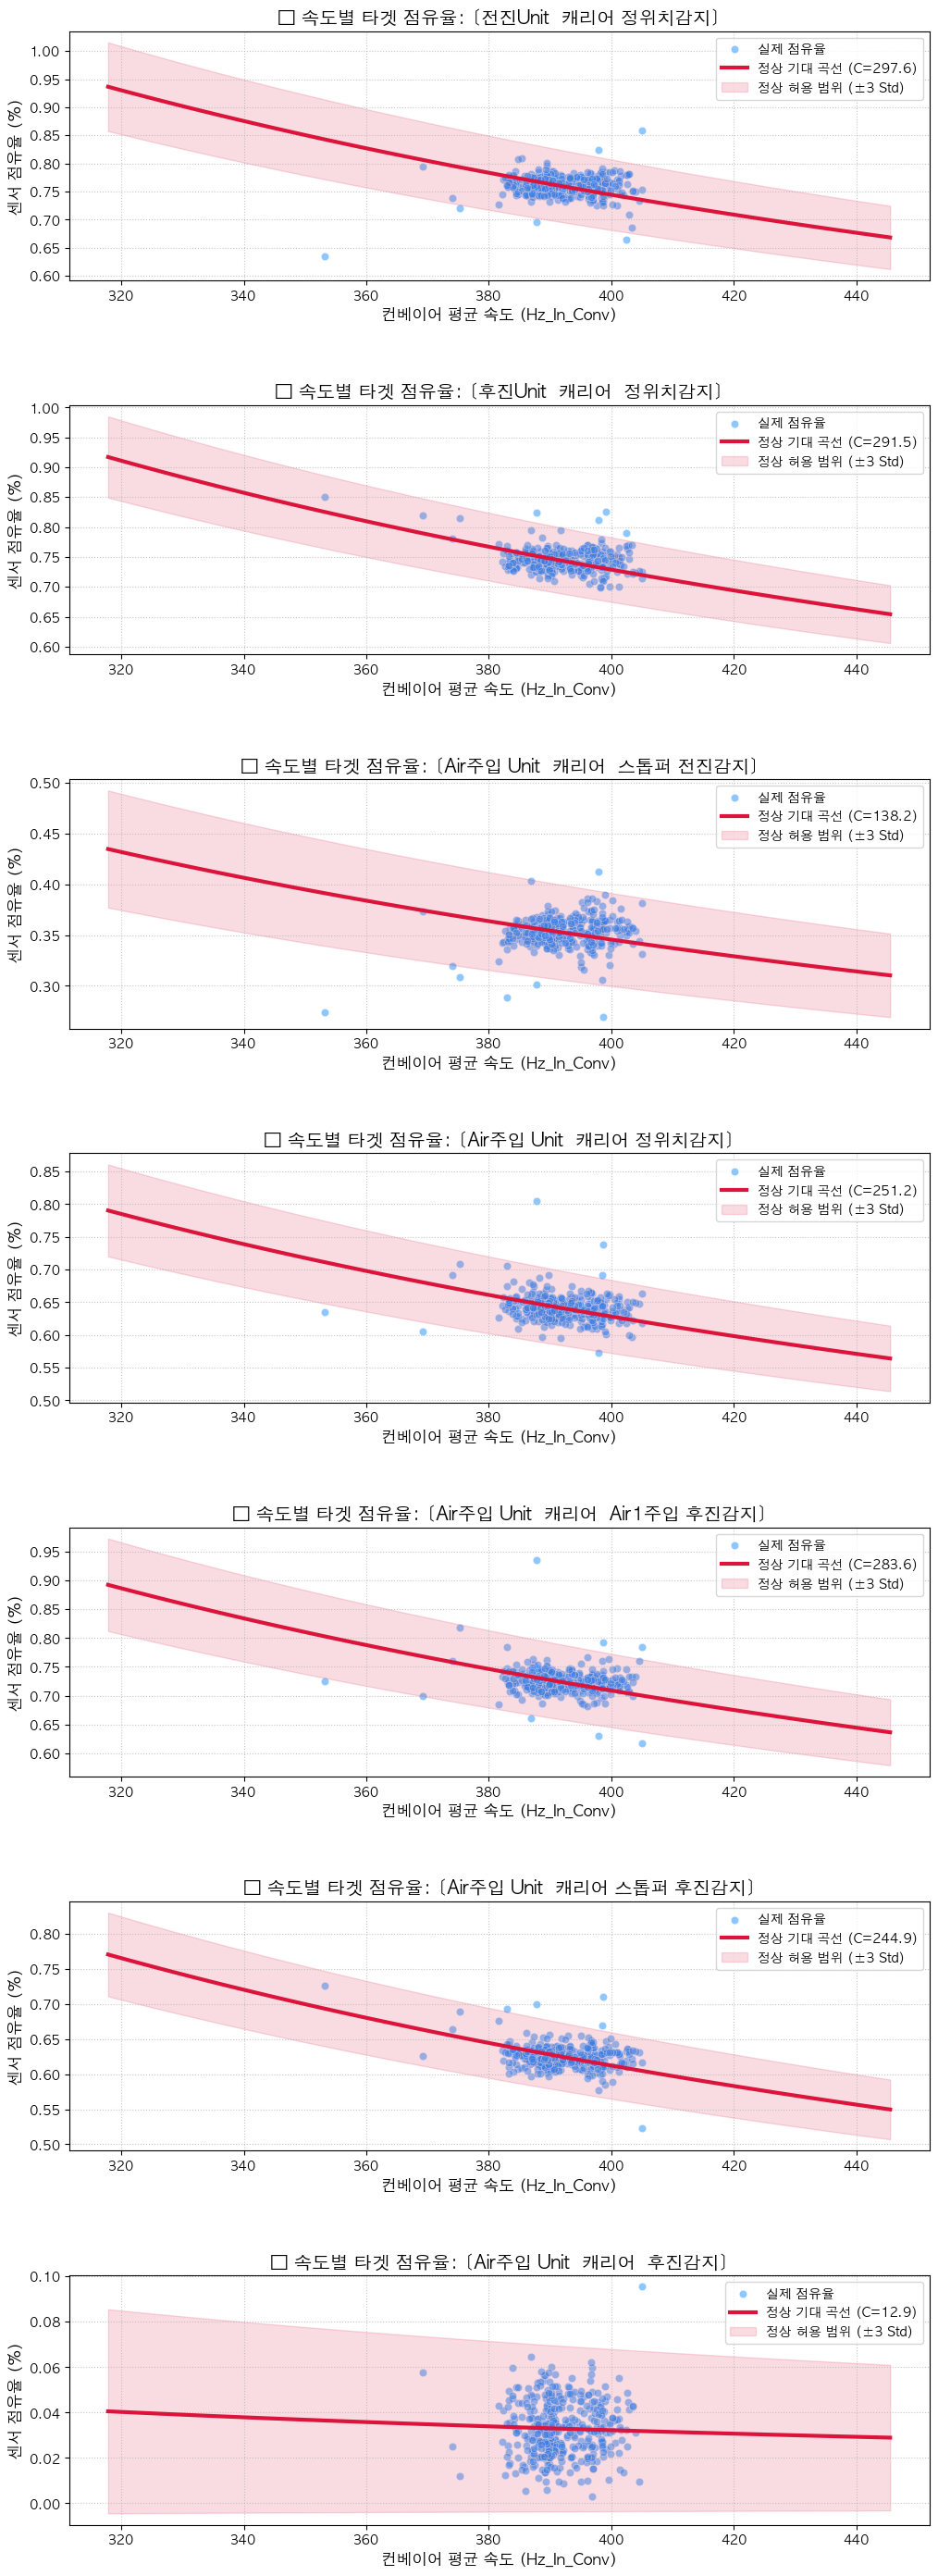

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==========================================
# 한글 폰트 세팅
# ==========================================
if os.name == 'nt': 
    plt.rc('font', family='Malgun Gothic')
else: 
    plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

def plot_expected_duty_curve(macro_df):
    print("📈 컨베이어 속도에 따른 [정상 점유율 기대 곡선]을 그립니다...")
    
    # 분석할 원본 센서 점유율 컬럼들 찾기 (Load_Score 말고 원본 이름들)
    boolean_sensors = [
        "전진Unit  캐리어 정위치감지", "후진Unit  캐리어  정위치감지",
        "Air주입 Unit  캐리어  스톱퍼 전진감지", "Air주입 Unit  캐리어 정위치감지",
        "Air주입 Unit  캐리어  Air1주입 후진감지", "Air주입 Unit  캐리어 스톱퍼 후진감지",
        "Air주입 Unit  캐리어  후진감지"
    ]
    
    # 데이터프레임에 있는 센서만 필터링
    sensors_in_df = [s for s in boolean_sensors if s in macro_df.columns]
    
    fig, axes = plt.subplots(len(sensors_in_df), 1, figsize=(12, 5 * len(sensors_in_df)))
    plt.subplots_adjust(hspace=0.5)
    
    if len(sensors_in_df) == 1:
        axes = [axes]
        
    # X축(속도) 그리기용 배열 (예: 150Hz ~ 500Hz)
    x_speeds = np.linspace(macro_df['Hz_In_Conv'].min() * 0.9, macro_df['Hz_In_Conv'].max() * 1.1, 100)
    
    for ax, sensor in zip(axes, sensors_in_df):
        valid_df = macro_df[macro_df[sensor] > 0]
        if valid_df.empty:
            continue
            
        # 1. 실제 데이터 산점도 (파란 점)
        sns.scatterplot(data=valid_df, x='Hz_In_Conv', y=sensor, ax=ax, alpha=0.5, color='dodgerblue', label='실제 점유율')
        
        # 2. 정상 Load Score 상수(C) 계산 (평균값)
        c_mean = (valid_df[sensor] * valid_df['Hz_In_Conv']).mean()
        c_std = (valid_df[sensor] * valid_df['Hz_In_Conv']).std()
        
        # 3. [핵심] 예상 점유율 곡선 (y = C / x) 그리기 (빨간 선)
        y_expected = c_mean / x_speeds
        ax.plot(x_speeds, y_expected, color='crimson', linewidth=3, label=f'정상 기대 곡선 (C={c_mean:.1f})')
        
        # 4. 허용 오차 범위 곡선 (±3 Sigma)
        y_upper = (c_mean + 3*c_std) / x_speeds
        y_lower = (c_mean - 3*c_std) / x_speeds
        ax.fill_between(x_speeds, y_lower, y_upper, color='crimson', alpha=0.15, label='정상 허용 범위 (±3 Std)')
        
        # 그래프 꾸미기
        ax.set_title(f"🔍 속도별 타겟 점유율: [{sensor}]", fontsize=14, fontweight='bold')
        ax.set_xlabel("컨베이어 평균 속도 (Hz_In_Conv)", fontsize=12)
        ax.set_ylabel("센서 점유율 (%)", fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.7)
        
    plt.show()

# 🚀 실행 
# 아까 롤링으로 뽑은 macro_df(원본 센서 컬럼이 살아있는 데이터프레임)를 넣으시면 됩니다.
plot_expected_duty_curve(final_macro_features) 